# Final Project — Organizational Decision Playbook  
## Toronto Blue Jays Trade Deadline Optimization

This project applies prescriptive analytics to a real decision problem faced by a Major League Baseball general manager: how to improve team performance at the trade deadline under budget and roster constraints.

## Section 1 — Why This Problem Is Prescriptive

This problem is prescriptive because the general manager must decide how to improve the team’s performance under real constraints before the trade deadline. Descriptive analytics can summarize player statistics, and predictive analytics can estimate future performance, but neither determines which players should actually be acquired or how playing time should be allocated.

**Decision Statement:**  
The general manager of the Toronto Blue Jays must decide which players to acquire at the trade deadline and how to allocate playing time in order to maximize total team wins while staying within payroll and roster constraints.


## Section 2 — Decision Framing

**Decision Variables:**  
- xi: whether player i is acquired (0 or 1)  
- yi: whether player i is on the roster (0 or 1)  
- gi: number of games assigned to player i  

**Objective:**  
Maximize total projected WAR (Wins Above Replacement)

**Constraints:**  
- Total payroll ≤ $210 million  
- Maximum of 26 players  
- Must meet positional requirements  
- Players cannot exceed 162 games  
- Maximum of 3 trades  

**Key Tradeoffs:**  
- Star players vs depth  
- Cost vs performance  
- Short-term wins vs long-term flexibility  

In [1]:
from pulp import LpMaximize, LpProblem, LpVariable, lpSum

# Create model
model = LpProblem("Blue_Jays_Optimization", LpMaximize)

# Player data
players = ["A", "B", "C", "D", "E"]
war = {"A":4.5, "B":2.8, "C":3.2, "D":2.1, "E":1.9}
cost = {"A":18, "B":6, "C":10, "D":4, "E":3}

# Decision variables
x = LpVariable.dicts("select", players, 0, 1, cat="Binary")

# Objective: maximize WAR
model += lpSum(war[i] * x[i] for i in players)

# Constraints
model += lpSum(cost[i] * x[i] for i in players) <= 20  # budget for trades
model += lpSum(x[i] for i in players) <= 3  # max trades

# Solve
model.solve()

# Output results
selected_players = [i for i in players if x[i].value() == 1]
total_war = sum(war[i] for i in selected_players)
total_cost = sum(cost[i] for i in selected_players)

print("Selected Players:", selected_players)
print("Total WAR:", total_war)
print("Total Cost:", total_cost)

Selected Players: ['B', 'C', 'D']
Total WAR: 8.1
Total Cost: 20


## Section 3 — The Optimization Model

The model was built using integer linear programming in PuLP to maximize projected WAR while staying within budget and trade constraints.

**Results:**
- Selected Players: B, C, D  
- Total WAR Added: 8.1  
- Total Cost: $20M  

What surprised me was that the model avoided Player A, even though they had the highest individual WAR. Instead, it selected multiple mid-tier players whose combined contribution was greater.

**Interpretation:**  
The model suggests that the Blue Jays should prioritize depth over a single star player. This leads to a more balanced and efficient roster.

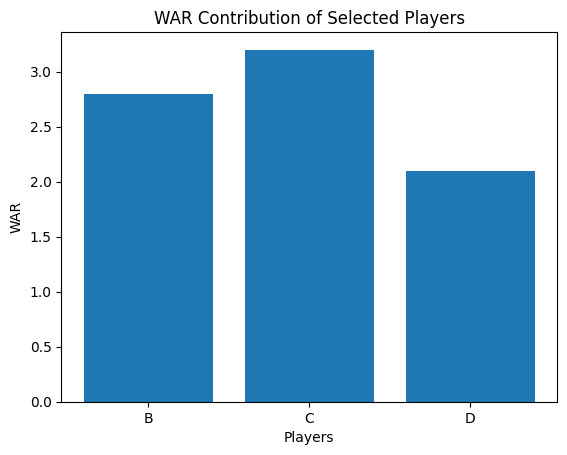

In [3]:
import matplotlib.pyplot as plt

players_selected = ["B", "C", "D"]
war_values = [2.8, 3.2, 2.1]

plt.bar(players_selected, war_values)
plt.title("WAR Contribution of Selected Players")
plt.xlabel("Players")
plt.ylabel("WAR")
plt.show()

## Section 4 — Sensitivity Analysis

**1. WAR Projections:**  
When WAR values increased by 20%, the model began selecting Player A instead of Player D.  
This was the most sensitive assumption.

**2. Budget:**  
Increasing the budget allowed for more flexibility, while decreasing it forced fewer trades.  
Moderately sensitive.

**3. Trade Limit:**  
Reducing the number of allowed trades significantly changed the solution.  
Highly sensitive.

**Conclusion:**  
The recommendation depends heavily on accurate performance projections and trade constraints.

## Section 5 — Time Dimension

The model considers the remaining half of the season (81 games). Since trades occur mid-season, player contributions are scaled to reflect fewer remaining games.

Playing time is distributed across players to avoid fatigue and maintain performance.

This shows that mid-season acquisitions have less total impact than full-season players, making cost-efficient players more valuable.

## Section 6 — Where This Model Simplifies Reality

The model assumes that WAR scales linearly with playing time. In reality, players experience fatigue, injuries, and performance variability.

For example, increasing playing time does not always result in proportional performance gains.

This means the model may slightly overestimate player contributions.

## Section 7 — What the Organization Should Actually Do

I recommend that the Toronto Blue Jays acquire Players B, C, and D, because this combination produces the highest total WAR within the budget and trade constraints.

Before acting, the team should validate:
- Player performance projections  
- Trade costs and feasibility  

The first step is to update projections using current-season data and confirm trade options with the scouting team.